In [ ]:
!pip install trimesh -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.5/745.5 kB 47.0 MB/s eta 0:00:00


In [ ]:
import json
import os

from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/pointcloud/params'

# Create the directory if it doesn't already exist
os.makedirs(save_dir, exist_ok=True)

file_path = os.path.join(save_dir, 'parameters.json')

# 1. Define your program parameters in a dictionary
parameters = {
    "pixel_pitch": 3.74e-6,
    "wavelength": 632.8e-9,
    "axis_dist": 0.9999,
    "img_width": 3840,
    "img_height": 2180,
    "target_vram_gb": 10.0,
    "generate_hologram": True,
    "optimize_gs": True,
    "img_path": "/content/drive/MyDrive/pointcloud/CGHs/zmienNazwe.png",
}

# 2. Save the parameters to a JSON file
with open(file_path, "w") as json_file:
    # indent=4 formats the file to be easily readable by humans
    json.dump(parameters, json_file, indent=4)

print("Parameters successfully saved to: ",file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Parameters successfully saved to:  /content/drive/MyDrive/pointcloud/params/parameters.json


In [ ]:
params_path = '/content/drive/MyDrive/pointcloud/params/parameters.json'

with open(params_path, "r") as json_file:
    loaded_params = json.load(json_file)

# Load the global program parameters

pixel_pitch = loaded_params["pixel_pitch"]
wavelength = loaded_params["wavelength"]
axis_dist = loaded_params["axis_dist"]
width = loaded_params["img_width"]
height = loaded_params["img_height"]
target_vram_gb = loaded_params["target_vram_gb"]
generate_hologram = loaded_params["generate_hologram"]
optimize_gs = loaded_params["optimize_gs"]
img_path = loaded_params["img_path"]

# instrukcja warunkowa optymalizacji GS
if generate_hologram != True:
    optimize_gs = False
    print("Tryb odczytu jest włączony. Ustaw generate_holograms na TRUE")

In [ ]:
!pip install moderngl trimesh pyrr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/51.2 kB 6.5 MB/s eta 0:00:00


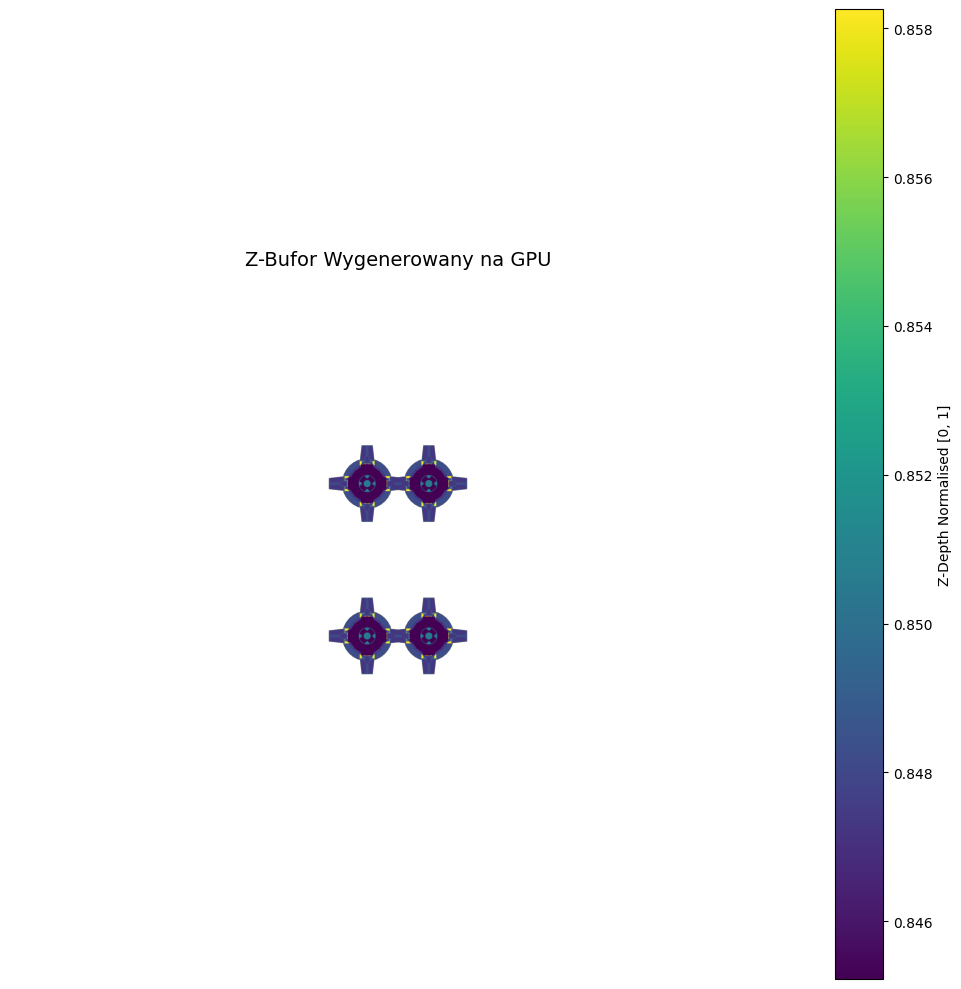

In [ ]:
import numpy as np
import trimesh
import moderngl
import matplotlib.pyplot as plt
from pyrr import Matrix44 # Lekka biblioteka do macierzy transformacji

# =====================================================================
# KROK 1: WCZYTANIE MODELU
# =====================================================================
filename = "/content/drive/MyDrive/pointcloud/ATAT.glb"
mesh = trimesh.load(filename, force='mesh')
vertices = mesh.vertices.astype('f4') # GPU wymaga float32
faces = mesh.faces.astype('i4')

# =====================================================================
# KROK 2: INICJALIZACJA KONTEKSTU GPU (Headless)
# =====================================================================
# Tworzymy niezależny kontekst OpenGL bez otwierania okna systemu operacyjnego
ctx = moderngl.create_context(standalone=True, backend='egl')
ctx.enable(moderngl.DEPTH_TEST) # Włączenie sprzętowego Z-bufora

# =====================================================================
# KROK 3: SHADERY (Programy wykonywane bezpośrednio na rdzeniach GPU)
# =====================================================================

# Vertex Shader (Zastępuje Twoją funkcję project_and_scale)
# GPU przetwarza tu każdy wierzchołek równolegle.
vertex_shader = '''
#version 330
in vec3 in_position;
uniform mat4 ortho_matrix;

void main() {
    // Mnożenie przez macierz załatwia centrowanie i skalowanie
    gl_Position = ortho_matrix * vec4(in_position, 1.0);
}
'''

# Fragment Shader (Wykonywany dla każdego wygenerowanego piksela)
fragment_shader = '''
#version 330
out vec4 fragColor;

void main() {
    // gl_FragCoord.z to sprzętowo obliczona głębokość (współrzędne barycentryczne
    // i interpolacja Z zostały już wykonane przez układ rasteryzatora GPU).
    // Zapisujemy głębię do bufora koloru, aby łatwo ją wyciągnąć do Numpy.
    float depth = gl_FragCoord.z;
    fragColor = vec4(depth, depth, depth, 1.0);
}
'''

prog = ctx.program(vertex_shader=vertex_shader, fragment_shader=fragment_shader)

# =====================================================================
# KROK 4: MACIERZ ORTOGRAFICZNA (Zastępuje Bounding Box i scale)
# =====================================================================
x_min, y_min, z_min = vertices.min(axis=0)
x_max, y_max, z_max = vertices.max(axis=0)

# =====================================================================
# KROK 4: MACIERZ ORTOGRAFICZNA (Z kompensacją Aspect Ratio)
# =====================================================================
x_range = x_max - x_min
y_range = y_max - y_min
z_range = z_max - z_min
# Używamy pełnego zakresu modelu z marginesem 20%, tak jak w kodzie CPU
max_range = max(x_range, y_range, z_range) * 1.2

# Odtwarzamy idealną, jednorodną skalę z kodu programowego CPU
scale = min(width, height) / max_range

# Zamiast przypisywać sztywny 'max_range' do osi X i Y,
# dostosowujemy rozpiętość kamery do fizycznych pikseli bufora.
# To gwarantuje zachowanie proporcji nawet na asymetrycznych ekranach.
x_span = width / (2.0 * scale)
y_span = height / (2.0 * scale)

# Oś Z nie podlega sprzętowemu dopasowaniu do ekranu (Viewport Transform),
# więc jej rozpiętość zostawiamy zgodnie z gabarytami modelu (połowa zakresu).
z_span = max_range / 2.0

x_center = (x_max + x_min) / 2.0
y_center = (y_max + y_min) / 2.0
z_center = (z_max + z_min) / 2.0

near_plane = z_center - z_span
far_plane = z_center + z_span

# Generujemy asymetryczną macierz rzutowania, która anuluje błędy pikseli prostokątnych
ortho_matrix = Matrix44.orthogonal_projection(
    x_center - x_span, x_center + x_span,  # left, right
    y_center - y_span, y_center + y_span,  # bottom, top
    near_plane, far_plane                  # near, far
).astype('f4')

prog['ortho_matrix'].write(ortho_matrix.tobytes())

# =====================================================================
# KROK 5: BUFORY GPU (VBO, IBO, FBO)
# =====================================================================
# 1. Przerzucamy wierzchołki i indeksy trójkątów z RAM do VRAM
vbo = ctx.buffer(vertices.tobytes())
ibo = ctx.buffer(faces.tobytes())
vao = ctx.vertex_array(prog, [(vbo, '3f', 'in_position')], index_buffer=ibo)

# 2. Tworzymy Framebuffer Object (FBO) - to nasz cyfrowy "ekran" w pamięci
color_renderbuffer = ctx.renderbuffer((width, height), components=1, dtype='f4')
depth_renderbuffer = ctx.depth_renderbuffer((width, height))
fbo = ctx.framebuffer(color_attachments=[color_renderbuffer], depth_attachment=depth_renderbuffer)
fbo.use()

# =====================================================================
# KROK 6: RASTERYZACJA SPRZĘTOWA
# =====================================================================
fbo.clear(red=1.0, green=1.0, blue=1.0, depth=1.0) # 1.0 w głębi to nieskończoność
vao.render(moderngl.TRIANGLES)

# =====================================================================
# KROK 7: POBRANIE WYNIKÓW Z VRAM DO NUMPY
# =====================================================================
# Odczytujemy jeden kanał z renderbuffera (ponieważ zapisaliśmy Z do kolorów R, G, B w shaderze)
raw_depth_data = fbo.read(components=1, dtype='f4')
z_buffer = np.frombuffer(raw_depth_data, dtype='f4').reshape((height, width))

# Odwracamy w osi Y, ponieważ OpenGL ma środek układu (0,0) w lewym dolnym rogu
z_buffer = np.flipud(z_buffer)

# =====================================================================
# WIZUALIZACJA
# =====================================================================
plt.figure(figsize=(10, 10))
# Maskujemy wartości tła (gdzie depth == 1.0) dla estetyki
masked_z = np.ma.masked_where(z_buffer >= 0.9999, z_buffer)
plt.imshow(masked_z, cmap='viridis')
plt.title("Z-Bufor Wygenerowany na GPU", fontsize=14)
plt.colorbar(label='Z-Depth Normalised [0, 1]')
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import trimesh

# =====================================================================
# KROK 7: ZAPIS CHMURY PUNKTÓW DO PLIKU PLY (Architektura GPU)
# =====================================================================

# 1. Identyfikacja poprawnych fragmentów.
# Szukamy pikseli, gdzie Z jest mniejsze niż 1.0 (tło).
# Używamy tolerancji < 0.9999 z powodu specyfiki zapisu zmiennoprzecinkowego
# w pamięci VRAM (Depth24/Depth32F), aby uniknąć błędów zaokrągleń (floating point inaccuracies).
valid_y, valid_x = np.where(z_buffer < 0.9999)

# 2. Ekstrakcja głębokości z bufora
valid_z_normalized = z_buffer[valid_y, valid_x]

# =====================================================================
# UWAGA INŻYNIERYJNA: REKONSTRUKCJA GŁĘBOKOŚCI
# Zmienna `valid_z_normalized` przechowuje wartości od 0.0 do 1.0.
# Jeśli wstawisz je bezpośrednio obok `valid_x` (np. 500 px) i `valid_y`,
# Twoja chmura punktów będzie drastycznie "spłaszczona" na osi Z.
#
# Aby przywrócić pierwotne proporcje (World Space), musimy odwrócić
# sprzętowe rzutowanie, korzystając z parametrów `near` i `far`,
# których użyliśmy w macierzy `ortho_matrix` (od -1000.0 do +1000.0).
# =====================================================================
# Mapowanie liniowe z [0, 1] powrót do skali obiektu

# 1. Dekompresja sprzętowa: powrót z [0, 1] do rzeczywistych jednostek świata
valid_z_world_absolute = (valid_z_normalized * (far_plane - near_plane)) + near_plane

# 2. Przejście do przestrzeni "pikseli" (aby zrównać proporcje z osiami X i Y)
# Używamy tej samej skali (scale), którą obliczyliśmy na początku dla ekranu.
valid_z_pixel_space = (valid_z_world_absolute - z_center) * scale

# 3. Budowa macierzy punktów o jednorodnych jednostkach (wszystko w skali ekranu)
point_cloud_array = np.column_stack((valid_x, valid_y, valid_z_pixel_space))


print(f"\nWygenerowano chmurę punktów z GPU Z-bufora! Liczba punktów: {len(point_cloud_array)}")

# 4. Inicjalizacja struktury i serializacja do pliku .ply
ply_filename = "/content/drive/MyDrive/pointcloud/zmienNazwe_gpu.ply"
pcd = trimesh.points.PointCloud(point_cloud_array)
pcd.export(ply_filename)

print(f"Pomyślnie zapisano sprzętową chmurę punktów do pliku: {ply_filename}")


Wygenerowano chmurę punktów z GPU Z-bufora! Liczba punktów: 46785
Pomyślnie zapisano sprzętową chmurę punktów do pliku: /content/drive/MyDrive/pointcloud/zmienNazwe_gpu.ply


In [ ]:
%reset -f

In [ ]:
# ================================

# edit z edycji 30082026

# Generowanie i rekonstrukcja hologramów nie jest wspierane w tej wersji programu

# wspierana wersja to sandbox_zapis29082026


# ================================

In [ ]:
import os

if generate_hologram:
    # 3. Zapisanie obrazu fazowego na Dysku Google
    # Domyślny folder na Dysku Google to "MyDrive"
    save_directory = '/content/drive/MyDrive/pointcloud/zbuffer'
    file_name = 'zmienNazwe.png'
    full_path = os.path.join(save_directory, file_name)

    # Zapisywanie obrazu za pomocą matplotlib
    # Używamy mapy kolorów 'gray' (odcienie szarości) lub 'hsv' (często stosowana do fazy)
    plt.imsave(full_path, z_buffer, cmap='gray')

    print(f"Pomyślnie zapisano obraz fazowy pod adresem: {full_path}")

Pomyślnie zapisano obraz fazowy pod adresem: /content/drive/MyDrive/pointcloud/zbuffer/zmienNazwe.png


In [ ]:
pip install tqdm

In [ ]:
import torch
import time
from tqdm import tqdm

def generate_cgh_gpu(depth_map_cpu, pixel_pitch, wavelength, target_vram_gb=10.0):
    """Oblicza płaszczyznę hologramu na GPU z maksymalnym wykorzystaniem zasobów.

    Parameters:
    - depth_map_cpu: macierz NumPy/PyTorch (H, W) z mapą głębi [m]
    - pixel_pitch: rozmiar piksela [m]
    - wavelength: długość fali światła [m]
    - target_vram_gb: maksymalny limit pamięci VRAM w GB przeznaczony na jedną paczkę
    """

    if not torch.cuda.is_available():
        raise SystemError(
            "Brak dostępnej karty NVIDIA z obsługą CUDA! Obliczenia na GPU niemożliwe."
        )

    device = torch.device("cuda")
    print(f"Uruchamianie na GPU: {torch.cuda.get_device_name(0)}")

    height, width = depth_map_cpu.shape
    k = torch.tensor(
        2 * 3.141592653589793 / wavelength, dtype=torch.float32, device=device
    )

    # 1. Tworzenie stałych siatek bezpośrednio w pamięci VRAM (FP32)
    y_idx, x_idx = torch.meshgrid(
        torch.arange(height, device=device, dtype=torch.float32),
        torch.arange(width, device=device, dtype=torch.float32),
        indexing="ij",
    )

    hologram_x = x_idx * pixel_pitch
    hologram_y = y_idx * pixel_pitch

    # 2. Przygotowanie ważnych punktów i wysłanie na GPU
    flat_depth = torch.tensor(
        depth_map_cpu * pixel_pitch, dtype=torch.float32, device=device
    ).flatten()
    flat_x = (x_idx * pixel_pitch).flatten()
    flat_y = (y_idx * pixel_pitch).flatten()

    valid_mask = flat_depth < 0.9999

    valid_x = flat_x[valid_mask]
    valid_y = flat_y[valid_mask]
    valid_z = flat_depth[valid_mask]

    num_points = valid_x.shape[0]

    # 3. Dynamiczne wyznaczenie BATCH_SIZE na podstawie dostępnej pamięci VRAM
    # Macierz (K, H, W) FP32 zajmuje: K * H * W * 4 B. Dodajemy zapas x4 na operacje pośrednie.
    bytes_per_point = height * width * 4 * 4
    target_bytes = target_vram_gb * 1024 * 1024 * 1024
    batch_size = max(1, int(target_bytes // bytes_per_point))

    print(
        f"Liczba punktów: {num_points} | Rozmiar paczki na GPU (batch): {batch_size}"
    )

    # Inicjalizacja skumulowanego pola optycznego na GPU (Complex64)
    hologram_field = torch.zeros(
        (height, width), dtype=torch.complex64, device=device
    )

    # 4. Pętla obliczeniowa w całości na GPU z paskiem postępu
    # Inicjalizujemy pasek postępu za pomocą tqdm
    pbar = tqdm(range(0, num_points, batch_size), desc="Obliczanie paczek")

    for start_idx in pbar:
        # Rozpoczęcie pomiaru czasu dla danej paczki
        batch_start_time = time.time()

        end_idx = min(start_idx + batch_size, num_points)

        # Pobieranie wycinka punktów (operacja bezkosztowa - w obrębie VRAM)
        b_x = valid_x[start_idx:end_idx].view(-1, 1, 1)
        b_y = valid_y[start_idx:end_idx].view(-1, 1, 1)
        b_z = valid_z[start_idx:end_idx].view(-1, 1, 1)

        # Wektorowe wyznaczenie odległości Euklidesowej w 3D dla paczki (K, H, W)
        physical_distance = 0.05

        dx = hologram_x - b_x
        dy = hologram_y - b_y
        dz = - b_z

        # Odległość r
        r = torch.sqrt(dx**2 + dy**2 + dz**2)

        # Obliczenie nakładania się fal z paczki: exp(i * k * r) / r
        # Używamy zmodyfikowanego wzoru Euler'a w PyTorch:
        batch_field = (
            torch.complex(torch.cos(k * r), torch.sin(k * r)) / r

            # odkomentuj ten wyraz jeśli chcesz zmienić intensywność wyrazu
            # torch.complex(torch.cos(k * r), torch.sin(k * r))
        )

        # Akumulacja sumy fal z paczki do końcowego hologramu
        hologram_field += torch.sum(batch_field, dim=0)

        # Synchronizacja GPU przed zmierzeniem czasu (czeka aż GPU skończy liczyć paczkę)
        torch.cuda.synchronize()

        # Zakończenie pomiaru czasu
        batch_time = time.time() - batch_start_time

        # Wyświetlenie czasu wykonania paczki obok paska postępu
        pbar.set_postfix({"Czas obliczeń [s]": f"{batch_time:.3f}"})

    # Zwracamy samą fazę z pola optycznego
    hologram_phase = torch.angle(hologram_field)

    # 5. Simulate 4-step Phase-Shifting Interference
    # Define a simple on-axis plane reference wave (amplitude matched to object wave for max contrast)
    ref_amplitude = torch.max(torch.abs(hologram_field))
    reference_wave = torch.full_like(hologram_field, ref_amplitude, dtype=torch.complex64)

    shifts = [0.0, 3.14159265359 / 2, 3.14159265359, 3 * 3.14159265359 / 2]
    intensity_frames = []

    for delta in shifts:
        # Create the phase-shifted reference beam
        phase_shift = torch.complex(
            torch.tensor(np.cos(delta), dtype=torch.float32, device=device),
            torch.tensor(np.sin(delta), dtype=torch.float32, device=device)
        )
        shifted_reference = reference_wave * phase_shift

        # Superimpose object and reference waves
        interference = hologram_field + shifted_reference

        # Camera sensor records intensity (amplitude squared), losing the direct phase
        intensity = torch.abs(interference) ** 2

        # Move to CPU to free VRAM, ready for image saving
        intensity_frames.append(intensity.cpu().numpy())

    # Returns a list of 4 NumPy matrices: [I1, I2, I3, I4]
    #return intensity_frames

    # returns a phase hologram
    return hologram_phase

    # --- PRZYKŁAD UŻYCIA ---
if __name__ == "__main__":
    import numpy as np

    # Tworzenie przykładowego bufora (aby skrypt był w pełni uruchamialny)
    # z_buffer = np.random.uniform(0.1, 0.5, (100, 100))
if generate_hologram:
    phase_result = generate_cgh_gpu(
        z_buffer, pixel_pitch, wavelength, target_vram_gb
    )
    print("Obliczenia na GPU zakończone sukcesem!")
else:
    print("Tryb odczytu jest włączony. Ustaw generate_holograms na TRUE")
    # Generowanie z wykorzystaniem do 10.0 GB VRAM



Uruchamianie na GPU: NVIDIA A100-SXM4-40GB
Liczba punktów: 8371200 | Rozmiar paczki na GPU (batch): 80


Obliczanie paczek:   3%|▎         | 3160/104640 [03:35<1:55:16, 14.67it/s, Czas obliczeń [s]=0.067]


KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def propagate_forward(field):
    """Propagates the wavefield from the Hologram (SLM) plane to the Image plane."""
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(field)))

def propagate_backward(field):
    """Propagates the wavefield from the Image plane back to the Hologram plane."""
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(field)))

def optimized_hybrid_gs(rendered_target_amplitude, initial_pcm_phase, iterations=30):
    # Start with the phase calculated from the Point Cloud Method
    slm_phase = initial_pcm_phase.copy()

    print(f"Starting optimized GS for {iterations} iterations...")

    for i in range(iterations):
        # Step A: Hologram Plane - Apply Phase-only SLM constraint
        slm_field = 1.0 * np.exp(1j * slm_phase)

        # Step B: Propagate to Image Plane
        image_field = propagate_forward(slm_field)

        # Step C: Image Plane - Apply PERFECT Rendered Target Constraint
        image_phase = np.angle(image_field)
        constrained_image_field = rendered_target_amplitude * np.exp(1j * image_phase)

        # Step D: Propagate back to Hologram Plane
        slm_field_back = propagate_backward(constrained_image_field)

        # Update the SLM phase for the next loop
        slm_phase = np.angle(slm_field_back)

    print("Optimization complete.")
    return slm_phase

# =====================================================================
# INTEGRATION WITH JUPYTER NOTEBOOK VARIABLES
# =====================================================================

# 1. CREATE TARGET AMPLITUDE FROM YOUR Z-BUFFER
# Your z_buffer has float('inf') for the background and numeric depth values for the object.
# We map the object to 1.0 (light) and the infinity background to 0.0 (dark).
if optimize_gs:
    target_amplitude = np.zeros_like(z_buffer, dtype=np.float32)
    target_amplitude[z_buffer != float('inf')] = 1.0

    # 2. EXTRACT PHASE SEED FROM PCM RESULT
    # phase_result was calculated on the GPU, so we must safely bring it back to CPU & Numpy
    if torch.is_tensor(phase_result):
        pcm_phase_seed = phase_result.cpu().numpy()
    else:
        pcm_phase_seed = phase_result

    # 3. RUN THE IMPROVED HYBRID ALGORITHM
    # We pass the clean, binary 2D mask AND the depth-accurate phase seed
    optimized_phase = optimized_hybrid_gs(target_amplitude, pcm_phase_seed, iterations=30)

    # 4. SIMULATE THE OPTICAL RECONSTRUCTION
    final_slm_field = 1.0 * np.exp(1j * optimized_phase)
    simulated_reconstruction = np.abs(propagate_forward(final_slm_field))

    # 5. PLOT THE RESULTS
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(target_amplitude, cmap='gray')
    axes[0].set_title("Target Amplitude Constraint\n(Derived directly from z_buffer)")
    axes[0].axis('off')

    axes[1].imshow(optimized_phase, cmap='twilight')
    axes[1].set_title("Optimized Phase-Only Hologram\n(To display on SLM)")
    axes[1].axis('off')

    axes[2].imshow(simulated_reconstruction, cmap='gray')
    axes[2].set_title("Simulated Optical Reconstruction\n(Phase-only result)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Tryb optymalizacji jest wyłączony. Ustaw optimize_gs na TRUE")

In [ ]:
device = torch.device("cuda")
print(f"Uruchamianie na GPU: {torch.cuda.get_device_name(0)}")

#[USUN TO] height, width = z_buffer.shape

y_idx, x_idx = torch.meshgrid(
    torch.arange(height, device=device, dtype=torch.float32),
    torch.arange(width, device=device, dtype=torch.float32),
    indexing="ij",
)

hologram_x = x_idx.cpu() * pixel_pitch
hologram_y = y_idx.cpu()* pixel_pitch
hologram_z = z_buffer * pixel_pitch

file_pathX = '/content/drive/MyDrive/pointcloud/tabledata/zmienNazwe.csv'
file_pathY = '/content/drive/MyDrive/pointcloud/tabledata/zmienNazwe2.csv'
file_pathZ = '/content/drive/MyDrive/pointcloud/tabledata/zmienNazwe3.csv'

np.savetxt(file_pathX, hologram_x, delimiter=",", fmt='%.6f')
np.savetxt(file_pathY, hologram_y, delimiter=",", fmt='%.6f')
np.savetxt(file_pathZ, hologram_z, delimiter=",", fmt='%.6f')


# 3. Save the matrix
# The fmt='%.6f' ensures it saves as a float with 6 decimal places
# (which perfectly aligns with float32's maximum precision limit).

print(f"float32 matrix saved to: {file_pathX}")
print(f"float32 matrix saved to: {file_pathY}")
print(f"float32 matrix saved to: {file_pathZ}")

In [ ]:
import torch
import gc

# 1. Wymuszenie usunięcia "sierot" z pamięci RAM
gc.collect()

# 2. Wyczyszczenie pamięci podręcznej VRAM na karcie graficznej
torch.cuda.empty_cache()

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
if generate_hologram:
    hologram_disp_pcm = phase_result.cpu().numpy().astype(np.float64)
    plt.imshow(hologram_disp_pcm, cmap='gray')
    plt.title(f"Matryca 2D zawierająca wartości fazy hologramu\nMetoda chmury punktów")
    plt.show()

    print(hologram_disp_pcm.dtype)

In [ ]:
if optimize_gs:
    hologram_disp = optimized_phase.astype(np.float64)

    plt.imshow(hologram_disp, cmap='gray')
    plt.title(f"Matryca 2D zawierająca wartości fazy hologramu\nMetoda Getchberga-Saxona")
    plt.show()
else:
    print("Tryb optymalizacji jest wyłączony. Ustaw optimize_gs na TRUE")

In [ ]:
import os

if generate_hologram:

    # 3. Zapisanie obrazu fazowego na Dysku Google
    # Domyślny folder na Dysku Google to "MyDrive"
    save_directory = '/content/drive/MyDrive/pointcloud/CGHs'
    file_name = 'zmienNazwe.png'
    full_path = os.path.join(save_directory, file_name)

    # Zapisywanie obrazu za pomocą matplotlib
    # Używamy mapy kolorów 'gray' (odcienie szarości) lub 'hsv' (często stosowana do fazy)
    plt.imsave(full_path, hologram_disp_pcm, cmap='gray')

    print(f"Pomyślnie zapisano obraz fazowy pod adresem: {full_path}")

In [ ]:
import os

if optimize_gs:

    # 3. Zapisanie obrazu fazowego na Dysku Google
    # Domyślny folder na Dysku Google to "MyDrive"
    save_directory = '/content/drive/MyDrive/pointcloud/CGHs'
    file_name = 'zmienNazwe.png'
    full_path = os.path.join(save_directory, file_name)

    # Zapisywanie obrazu za pomocą matplotlib
    # Używamy mapy kolorów 'gray' (odcienie szarości) lub 'hsv' (często stosowana do fazy)
    plt.imsave(full_path, hologram_disp, cmap='gray')

    print(f"Pomyślnie zapisano obraz fazowy pod adresem: {full_path}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def fresnel_reconstruct(hologram_path, z, wavelength, pixel_size):
    """
    Reconstructs a digital hologram using the Fresnel diffraction (FFT) method.

    Parameters:
    hologram_path (str): Path to the recorded hologram image file.
    z (float): Reconstruction distance in meters.
    wavelength (float): Wavelength of the laser used in meters.
    pixel_size (float): Pixel pitch of the camera sensor in meters.
    """

    # 1. Load the hologram and convert it to a 2D float array (grayscale)
    img = Image.open(hologram_path).convert('L')
    hologram = np.asarray(img, dtype=np.float64)

    # Get image dimensions (Ny = rows, Nx = columns)
    Ny, Nx = hologram.shape
    phase = (hologram / 255.0) * (2 * np.pi)
    U_initial = np.exp(1j * phase)

    pad_y, pad_x = Ny // 2, Nx // 2
    U_padded = np.pad(U_initial, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0)
    Ny_pad, Nx_pad = U_padded.shape


    # 2. Create the spatial coordinate grid
    # We center the grid at (0,0) to properly apply the spherical chirp function
    x = np.arange(-Nx_pad/2, Nx_pad/2) * pixel_size
    y = np.arange(-Ny_pad/2, Ny_pad/2) * pixel_size
    X, Y = np.meshgrid(x, y)


    # 4. Calculate the Inner Chirp Function
    # Equation: exp( i * pi / (lambda * z) * (X^2 + Y^2) )
    inner_chirp = np.exp(-1j * (np.pi / (wavelength * z)) * (X**2 + Y**2))

    # 5. Multiply the padded field by the inner chirp
    complex_field = U_padded * inner_chirp

    # 5. Perform the 2D Fast Fourier Transform
    # - ifftshift: aligns the center of our grid to the edges (expected by the FFT algorithm)
    # - fft2: computes the actual 2D Fourier Transform
    # - fftshift: moves the zero-frequency (DC) component back to the center of the image
    U = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(complex_field)))

    # 6. Calculate Output Coordinates and Outer Chirp (Crucial for correct Phase)
    # The pixel size in the reconstruction plane changes based on distance z
    dx_out = (wavelength * z) / (Nx_pad * pixel_size)
    dy_out = (wavelength * z) / (Ny_pad * pixel_size)

    x_out = np.arange(-Nx_pad/2, Nx_pad/2) * dx_out
    y_out = np.arange(-Ny_pad/2, Ny_pad/2) * dy_out
    X_out, Y_out = np.meshgrid(x_out, y_out)

    # Outer phase factor
    outer_chirp = np.exp(-1j * (np.pi / (wavelength * z)) * (X_out**2 + Y_out**2))

    # Final field: multiplied by outer chirp and physical constants (dx*dy for discrete integral)
    U_final = U * outer_chirp / (-1j * wavelength * z) * (pixel_size**2)


    # 7. Extract the Reconstructed Intensity and Phase
    intensity = np.abs(U_final)**2
    phase_recon = np.angle(U_final)

    intensity_log = np.log10(intensity + 1)

    # Calculate spatial extents for plotting (in millimeters for readability)
    extent_mm = [x_out[0]*1e3, x_out[-1]*1e3, y_out[-1]*1e3, y_out[0]*1e3]

    return intensity_log, phase, extent_mm

# ==========================================
# Example Usage
# ==========================================
if __name__ == "__main__":
    # Define your physical setup parameters
    if generate_hologram:
        IMAGE_PATH = img_path # Replace with your hologram image file
    else:
        image_dir = '/content/drive/MyDrive/pointcloud/CGHs'
        file_name = 'czlowiekPCM.png'
        print("Tryb odczytu jest włączony. Otwieram plik ",file_name)
        IMAGE_PATH = os.path.join(image_dir, file_name)

    try:
        # Run the reconstruction
        recon_intensity, recon_phase, extent_mm = fresnel_reconstruct(
            IMAGE_PATH, axis_dist, wavelength, pixel_pitch
        )

        # Plot the results
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Display Intensity
        ax1 = axes[0]
        im1 = ax1.imshow(recon_intensity, cmap='gray', extent=extent_mm, aspect = 'auto')
        ax1.set_title(f"Reconstructed Intensity (z={axis_dist}m)")
        fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

        # Display Phase
        ax2 = axes[1]
        im2 = ax2.imshow(recon_phase, cmap='gray', extent=extent_mm, aspect = 'auto')
        ax2.set_title("Reconstructed Phase")
        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"Error: Could not find the image ",IMAGE_PATH,". Please provide a valid hologram image path.")

In [ ]:
from scipy.signal import fftconvolve

def scaled_fresnel_czt(u_in, wvl, d, dx_in, dy_in, dx_out, dy_out):
    """
    Simulates wavefield diffraction using a single Chirp Z-Transform (CZT) step.
    This allows arbitrary scaling of the output plane pixel pitch (dx_out, dy_out),
    unlike standard FFT-based Fresnel propagation which locks the output scale.

    Parameters:
        u_in   : 2D complex numpy array of the input wavefield
        wvl    : Wavelength of the light (meters)
        d      : Propagation distance (meters). Negative for reconstruction.
        dx_in, dy_in   : Pixel pitch of the input plane (meters)
        dx_out, dy_out : Pixel pitch of the output plane (meters)
    """


    u_in = np.exp(1j * phase)

    Ny, Nx = u_in.shape

    # Create integer index grids for the input plane
    ny, nx = np.meshgrid(np.arange(-Ny//2, Ny//2),
                         np.arange(-Nx//2, Nx//2), indexing='ij')

    # Physical coordinates
    x1, y1 = nx * dx_in, ny * dy_in
    x2, y2 = nx * dx_out, ny * dy_out

    # Wavenumber
    k = 2 * np.pi / wvl

    # Scaling parameters for the Chirp Z-Transform
    alpha_x = (dx_in * dx_out) / (wvl * d)
    alpha_y = (dy_in * dy_out) / (wvl * d)

    # ---------------------------------------------------------
    # STEP 1: Input Plane Phase Multiplication
    # ---------------------------------------------------------
    # Standard Fresnel quadratic phase
    P_in = np.exp(1j * (k / (2 * d)) * (x1**2 + y1**2))

    # CZT pre-multiplication chirp (A-term)
    A_term = np.exp(-1j * np.pi * (alpha_x * nx**2 + alpha_y * ny**2))

    # Prepare the input matrix for convolution
    A = u_in * P_in * A_term

    # ---------------------------------------------------------
    # STEP 2: The Chirp Z-Transform (via FFT Convolution)
    # ---------------------------------------------------------
    # Generate the convolution kernel (B-term) for Bluestein's method.
    # It must be sized (2N-1) to evaluate the linear convolution fully.
    ny_B, nx_B = np.meshgrid(np.arange(-Ny+1, Ny),
                             np.arange(-Nx+1, Nx), indexing='ij')
    B = np.exp(1j * np.pi * (alpha_x * nx_B**2 + alpha_y * ny_B**2))

    # Perform the single Fast Fourier Transform step (convolution theorem)
    # fftconvolve automatically handles zero-padding and executes the FFT -> multiply -> IFFT
    S = fftconvolve(A, B, mode='valid')

    # ---------------------------------------------------------
    # STEP 3: Output Plane Phase Multiplication
    # ---------------------------------------------------------
    # CZT post-multiplication chirp (C-term)
    C_term = np.exp(-1j * np.pi * (alpha_x * nx**2 + alpha_y * ny**2))

    # Standard Fresnel quadratic phase for the output plane
    P_out = np.exp(1j * (k / (2 * d)) * (x2**2 + y2**2))

    # Final scaling and phase aggregation
    coeff = np.exp(1j * k * d) / (1j * wvl * d)

    # Multiply by the input area differential (dx_in * dy_in) for the integral
    u_out = coeff * S * C_term * P_out * (dx_in * dy_in)

    return u_out

In [ ]:
if __name__ == "__main__":

    img_path = '/content/drive/MyDrive/pointcloud/CGHs/czlowiekPCM.png'

    # --- 3. Simulate Diffraction (Forward Propagation) ---
    #print("Simulating wavefield diffraction (Forward CZT)...")
    #u_diffracted = scaled_fresnel_czt(img_path, wavelength, axis_dist, pixel_pitch, pixel_pitch, pixel_pitch, pixel_pitch)

    # The sensor captures intensity (Amplitude squared), destroying the phase.
    # This interference pattern is our Hologram.
    #hologram = np.abs(u_diffracted)**2

    # --- 4. Numerically Reconstruct the Hologram (Backward Propagation) ---
    print("Reconstructing hologram (Backward CZT)...")
    # CZT Magic: We can choose a SMALLER output pixel pitch to mathematically
    # "zoom in" on the reconstructed object without interpolation artifacts.


    # Propagate backwards (-d) using the generated hologram
    u_reconstructed = scaled_fresnel_czt(img_path, wavelength, -axis_dist, pixel_pitch, pixel_pitch, pixel_pitch, pixel_pitch)

    # --- 5. Visualization ---
    plt.figure(figsize=(14, 4))


    plt.subplot(1, 3, 2)
    plt.title("Diffracted Wavefield / Hologram")
    plt.imshow(recon_phase, cmap='gray')
    plt.xlabel("mm")

    plt.subplot(1, 3, 3)
    plt.title("Reconstructed Object (2x CZT Zoom)")
    plt.imshow(np.abs(u_reconstructed), cmap='gray')
    plt.xlabel("mm")

    plt.tight_layout()
    plt.show()